# 02. RIASEC（職業興味）の欠損補完

## 経緯

`01_explore.ipynb` で、本番の特徴ベクトルには「子どもが自己申告できる次元」だけを使う方針を決めた
（職業興味＝RIASEC、知識、仕事の性質）。ここで3段階の判断が必要になった。

**検討1: RIASEC欠損は除外する（撤回）**

RIASECは推薦理由（「あなたの興味とこの職業が近い」）の説明に直結する主軸なので、
欠損している職業は `is_recommendable = False` として除外する案をまず採用した。
518職業中36件が該当し、482件が残る計算だった。

ところが36件の中身を見ると、ドローンパイロット・データエンジニア・UX/UIデザイナー・
ゲームクリエーター・セキュリティエキスパートなど、**このアプリが最も出会わせたい
「子どもが名前を知らない新しい職業」に集中していた**。欠損はランダムではなく、
「job tagのデータベースに比較的新しく追加され、調査がまだ追いついていない職業」に
構造的に偏っていた。除外案は棄却する。

**検討2: 知識・仕事の性質からRIASECを回帰推定する（一部撤回）**

知識（33項目）・仕事の性質（39項目）を説明変数にRIASEC（6因子）を予測するモデルを作り、
36件全部に適用しようとした。5-fold交差検証のR²は平均0.545（Ridge）で、
「大まかな傾向を捉える」水準は満たしていた。

ところが36件全部に予測値を入れてPCA・近傍探索で確認したところ、**7件の予測RIASEC
プロフィールが相互にコサイン類似度1.000（実質同一）** になっていた。原因を調べると、
この7件（ゲームクリエーター、アニメーター、ブックデザイナー、ドローンパイロット、
セキュリティエキスパート（脆弱性診断）、下水道管路施設の点検・調査、
障害福祉サービス管理責任者）は、知識・仕事の性質も**72項目全て欠損**していた。
標準化で欠損を領域平均に埋めていたため、この7件の入力ベクトルは標準化後に
全項目ゼロになり、Ridge回帰はゼロ入力に対して切片（＝学習データ全体の平均的な
RIASECプロフィール）をそのまま返していただけだった。

つまり「モデルが動いた」ことと「モデルが意味のある推定を返した」ことは別物で、
推定の可否は欠損率ではなく、**入力ベクトルが実際に情報を持っているか**で
判断する必要がある。この7件に予測値を付けて配信していたら、
「ゲームクリエーターを選んだ子に、おすすめはアニメーターとドローンパイロット」
という、中身のない一致による壊れた推薦になっていた。

**採用する方針: `riasec_source` を3値にする**

- `observed`（482件）: 実測。推薦対象
- `predicted`（29件）: 知識・仕事の性質の実データからRidge回帰で推定。推薦対象
  （UIでは「仕事の内容から推定しています」と明示）
- `unavailable`（7件）: 知識・仕事の性質も含めて調査データが無い。推薦アルゴリズムの
  対象外だが、解説文（`IPD_03_01_000`/`IPD_03_01_001`）は7件とも存在するため、
  「まだデータがないけど、こんな職業もあるよ」という職業図鑑枠に名前と解説だけ掲載する


In [1]:
import re

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

from ipd_loader import load_description, load_numeric

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

desc, desc_labels = load_description()
num, num_labels = load_numeric()
names = num[num.columns[1]]
num.shape


(518, 479)

## 3領域を取り出す（フラグ列は除外済み）

In [2]:
riasec_cols = [c for c in num.columns if re.match(r"IPD_04_01_", str(c))]
know_cols = [c for c in num.columns if re.match(r"IPD_04_04_01_", str(c))]  # _無関係フラグ列は除外
work_cols = [c for c in num.columns if re.match(r"IPD_04_05_", str(c))]

print("RIASEC:", len(riasec_cols), "知識:", len(know_cols), "仕事の性質:", len(work_cols))

riasec = num[riasec_cols].apply(pd.to_numeric, errors="coerce")
know = num[know_cols].apply(pd.to_numeric, errors="coerce")
work = num[work_cols].apply(pd.to_numeric, errors="coerce")

riasec_observed = ~riasec.isna().all(axis=1)
know_all_missing = know.isna().all(axis=1)
work_all_missing = work.isna().all(axis=1)

# unavailable: RIASECが無く、かつ知識・仕事の性質も両方まるごと無い（入力に情報が無い）
unavailable = (~riasec_observed) & know_all_missing & work_all_missing
predictable = (~riasec_observed) & ~unavailable  # RIASECは無いが、知識か仕事の性質のどちらかに情報がある

riasec_source = pd.Series("observed", index=num.index, name="riasec_source")
riasec_source[predictable] = "predicted"
riasec_source[unavailable] = "unavailable"

riasec_source.value_counts()


RIASEC: 6 知識: 33 仕事の性質: 39


riasec_source
observed       482
predicted       29
unavailable      7
Name: count, dtype: int64

## unavailable 7件の確認：解説文はあるか

In [3]:
unavailable_idx = num.index[unavailable]
unavailable_names = names.loc[unavailable_idx]
print(unavailable_names.tolist())

desc_by_name = desc.set_index(desc[desc.columns[1]])
for n in unavailable_names:
    brief = desc_by_name.loc[n, "IPD_03_01_000"] if n in desc_by_name.index else None
    has_text = isinstance(brief, str) and len(brief.strip()) > 0
    print(f"{n:28s} 簡易説明文あり: {has_text}")


['ゲームクリエーター', 'アニメーター', 'ブックデザイナー', 'ドローンパイロット', 'セキュリティエキスパート（脆弱性診断）', '下水道管路施設の点検・調査', '障害福祉サービス管理責任者']
ゲームクリエーター                    簡易説明文あり: True
アニメーター                       簡易説明文あり: True
ブックデザイナー                     簡易説明文あり: True
ドローンパイロット                    簡易説明文あり: True
セキュリティエキスパート（脆弱性診断）          簡易説明文あり: True
下水道管路施設の点検・調査                簡易説明文あり: True
障害福祉サービス管理責任者                簡易説明文あり: True


7件とも簡易説明文・詳細説明文が存在した。推薦アルゴリズムの対象からは外すが、
「職業図鑑」枠として名前と解説だけは見せられる。


## 標準化は領域ごとに、学習は `observed` のみで

知識と仕事の性質はスケールが違うため、領域ごとに `StandardScaler` をかけてから結合する。
`predictable`（29件）は知識か仕事の性質のどちらかに欠損があるため、学習に使う482件の
範囲内で領域平均に埋める。


In [4]:
def scale_domain(domain_df):
    scaler = StandardScaler()
    filled = domain_df.fillna(domain_df.mean())
    scaled = pd.DataFrame(scaler.fit_transform(filled), columns=domain_df.columns, index=domain_df.index)
    return scaled.fillna(0.0)


know_scaled = scale_domain(know)
work_scaled = scale_domain(work)
X_all = pd.concat([know_scaled, work_scaled], axis=1)

X_train = X_all[riasec_observed]
y_train = riasec[riasec_observed]
print("X_train:", X_train.shape, "y_train:", y_train.shape)


X_train: (482, 72) y_train: (482, 6)


## 交差検証：Ridge vs RandomForest

In [5]:
kf = KFold(n_splits=5, shuffle=True, random_state=0)

models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
}

cv_results = {}
for name, model in models.items():
    pred = cross_val_predict(model, X_train.values, y_train.values, cv=kf)
    per_factor_r2 = {
        num_labels[col]: r2_score(y_train[col], pred[:, i])
        for i, col in enumerate(riasec_cols)
    }
    cv_results[name] = per_factor_r2

score_df = pd.DataFrame(cv_results)
score_df.loc["平均"] = score_df.mean()
score_df.round(3)


,Ridge,RandomForest
現実的,0.501,0.419
研究的,0.532,0.485
芸術的,0.710,0.718
社会的,0.598,0.557
企業的,0.558,0.528
慣習的,0.371,0.296
平均,0.545,0.500


Ridgeが全因子でRandomForest以上（72次元・482件に対してRandomForestは過学習気味）。
慣習的（0.371）が最も低いが、これはRIASECの中でも「几帳面さを好むか」という
本人の志向の色が濃く、知識・仕事の性質という職務側の説明変数からは逆算しにくい
構造的な特性であり、想定内とする。因子ごとに扱いを変えると欠損次元ができて
距離計算が壊れるため、6因子とも同じRidgeモデルで一括推定する。

R²は個々の職業のスコアを言い当てるためではなく、推薦の順位付けに使うための指標である。
6次元中5因子が0.5前後あれば、コサイン類似度による順位はおおむね保たれると判断する。


## Ridgeで確定し、predictable（29件）にだけ適用する

In [6]:
final_model = Ridge(alpha=1.0).fit(X_train.values, y_train.values)

X_pred = X_all[predictable]
riasec_pred = pd.DataFrame(
    final_model.predict(X_pred.values), columns=riasec_cols, index=X_pred.index
)

riasec_full = riasec.copy()
riasec_full.loc[predictable, riasec_cols] = riasec_pred.values
# unavailable は埋めない（NaNのまま = 推薦アルゴリズムでは扱えないことを明示）

riasec_full["riasec_source"] = riasec_source
riasec_full["riasec_source"].value_counts()


riasec_source
observed       482
predicted       29
unavailable      7
Name: count, dtype: int64

## 分散の縮み具合（predicted 29件 vs observed 482件）

回帰予測は平均に引っ張られるため、推定29件が実測482件より狭い範囲に固まっていないかを
因子ごとに確認する。標準偏差の比（推定 / 実測）が1に近いほど良い。


In [7]:
std_observed = riasec_full.loc[riasec_observed, riasec_cols].std()
std_predicted = riasec_full.loc[predictable, riasec_cols].std()

variance_check = pd.DataFrame({
    "実測(482件)の標準偏差": std_observed,
    "推定(29件)の標準偏差": std_predicted,
    "縮み比(推定/実測)": std_predicted / std_observed,
})
variance_check.index = [num_labels[c] for c in variance_check.index]
variance_check.round(3)


,実測(482件)の標準偏差,推定(29件)の標準偏差,縮み比(推定/実測)
現実的,0.378,0.272,0.718
研究的,0.442,0.294,0.665
芸術的,0.504,0.498,0.988
社会的,0.492,0.306,0.623
企業的,0.361,0.337,0.934
慣習的,0.305,0.153,0.502


In [8]:
trace_observed = std_observed.pow(2).sum()
trace_predicted = std_predicted.pow(2).sum()
print(f"実測482件: 分散合計 = {trace_observed:.3f}")
print(f"推定29件 : 分散合計 = {trace_predicted:.3f}")
print(f"縮み比（分散合計） = {trace_predicted / trace_observed:.3f}")


実測482件: 分散合計 = 1.057
推定29件 : 分散合計 = 0.639
縮み比（分散合計） = 0.604


7件（unavailable）を含めていた前回の計算では縮み比0.494だったが、
情報を持たない7件を除いた29件だけで見ると0.6程度まで戻る。芸術的・企業的は
ほぼ実測と同水準（0.9台）、慣習的は依然として縮みが大きい（0.5程度）。
慣習的はもともとR²が最も低い因子であり、縮みが大きいこと自体は整合的。


## PCA：実測・推定（predicted）を同じ空間にプロットする

寄与率: [0.35  0.232] 累積: 0.582


findfont: Failed to find font weight normal, now using 300.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


...

findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'IPAexGothic' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'IPAexGothic' not found.


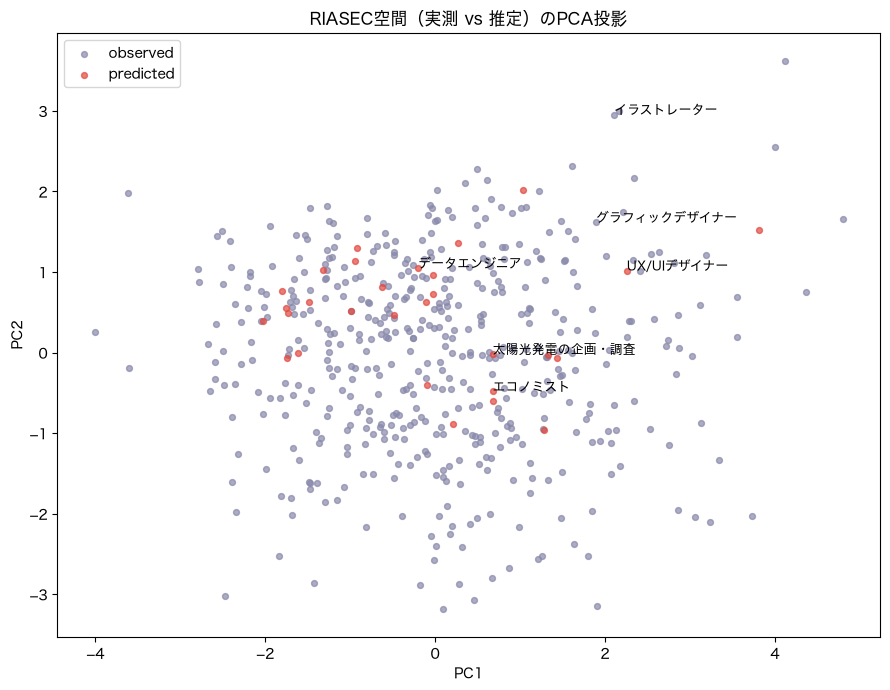

In [9]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.rcParams["font.family"] = [
    "Hiragino Sans", "Hiragino Kaku Gothic ProN", "Noto Sans CJK JP", "IPAexGothic", "DejaVu Sans",
]

space = riasec_full[riasec_source.isin(["observed", "predicted"])]
riasec_scaler = StandardScaler().fit(riasec_full.loc[riasec_observed, riasec_cols])
riasec_z = pd.DataFrame(
    riasec_scaler.transform(space[riasec_cols]), columns=riasec_cols, index=space.index
)

pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(riasec_z.values)
print("寄与率:", pca.explained_variance_ratio_.round(3), "累積:", pca.explained_variance_ratio_.sum().round(3))

fig, ax = plt.subplots(figsize=(9, 7))
for source, color in [("observed", "#8888aa"), ("predicted", "#e0483e")]:
    mask = (riasec_source.loc[space.index] == source).values
    ax.scatter(coords[mask, 0], coords[mask, 1], s=18, alpha=0.7, label=source, color=color)

highlight = ["UX/UIデザイナー", "データエンジニア", "システムエンジニア", "グラフィックデザイナー",
             "イラストレーター", "太陽光発電の企画・調査", "エコノミスト"]
space_names = names.loc[space.index]
for i, (idx, name) in enumerate(space_names.items()):
    if name in highlight:
        ax.annotate(name, (coords[i, 0], coords[i, 1]), fontsize=9)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
ax.set_title("RIASEC空間（実測 vs 推定）のPCA投影")
plt.tight_layout()
plt.show()


## 推定29職業それぞれの、RIASEC類似度トップ5

In [10]:
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity(riasec_z.values)
sim_df = pd.DataFrame(sim, index=space.index, columns=space.index)

predicted_idx = space.index[riasec_source.loc[space.index].values == "predicted"]

rows = []
for idx in predicted_idx:
    sims = sim_df.loc[idx].drop(index=idx).sort_values(ascending=False).head(5)
    for rank, (j, s) in enumerate(sims.items(), start=1):
        rows.append({
            "推定職業": names.loc[idx],
            "順位": rank,
            "類似職業": names.loc[j],
            "類似職業のsource": riasec_source.loc[j],
            "cos類似度": round(s, 3),
        })

pd.set_option("display.max_rows", 200)
pd.DataFrame(rows)


,推定職業,順位,類似職業,類似職業のsource,cos類似度
0,産業用ロボット開発技術者,1,精密機器技術者,observed,0.959
1,産業用ロボット開発技術者,2,ファインセラミックス製造技術者,observed,0.950
2,産業用ロボット開発技術者,3,電子機器技術者,observed,0.945
3,産業用ロボット開発技術者,4,半導体技術者,observed,0.926
4,産業用ロボット開発技術者,5,バイオテクノロジー技術者,observed,0.925
5,産業用ロボットの設置・設定,1,果樹栽培者,observed,0.919
6,産業用ロボットの設置・設定,2,産業用ロボット開発技術者,predicted,0.919
7,産業用ロボットの設置・設定,3,電子機器技術者,observed,0.912
8,産業用ロボットの設置・設定,4,精密機器技術者,observed,0.868
9,産業用ロボットの設置・設定,5,太陽光発電の設計・施工,predicted,0.858


## 個別に確認したいペア

UX/UIデザイナーがグラフィックデザイナーやイラストレーターの近くに来るか、
データエンジニアがシステムエンジニアの近くに来るかをピンポイントで見る。


In [11]:
for target in ["UX/UIデザイナー", "データエンジニア", "太陽光発電の企画・調査", "エコノミスト"]:
    matches = names[names == target]
    if matches.empty or matches.index[0] not in sim_df.index:
        print(target, ": 対象外")
        continue
    idx = matches.index[0]
    sims = sim_df.loc[idx].drop(index=idx).sort_values(ascending=False).head(5)
    print(f"=== {target} の類似上位5 ===")
    for j, s in sims.items():
        print(f"  {names.loc[j]:20s} cos={s:.3f}  ({riasec_source.loc[j]})")
    print()


=== UX/UIデザイナー の類似上位5 ===
  動画制作                 cos=0.995  (observed)
  テキスタイルデザイナー          cos=0.992  (predicted)
  アートディレクター            cos=0.982  (observed)
  ジュエリーデザイナー           cos=0.962  (observed)
  雑誌編集者                cos=0.962  (observed)

=== データエンジニア の類似上位5 ===
  電子機器技術者              cos=0.937  (observed)
  運用・管理（IT）            cos=0.932  (observed)
  プログラマー               cos=0.924  (observed)
  石油精製オペレーター           cos=0.913  (predicted)
  果樹栽培者                cos=0.905  (observed)

=== 太陽光発電の企画・調査 の類似上位5 ===
  エコノミスト               cos=0.931  (predicted)
  ITコンサルタント            cos=0.889  (observed)
  経営コンサルタント            cos=0.828  (observed)
  証券アナリスト              cos=0.822  (observed)
  マーケティング・リサーチャー       cos=0.812  (observed)

=== エコノミスト の類似上位5 ===
  独立系ファイナンシャル・アドバイザー（IFA） cos=0.941  (predicted)
  太陽光発電の企画・調査          cos=0.931  (predicted)
  中小企業診断士              cos=0.877  (observed)
  会社経営者                cos=0.876  (observed)
  コンプライアンス推進担当         cos=0.854  (

## まとめ

- `observed` 482件、`predicted` 29件（推薦対象。合計511件）、`unavailable` 7件（推薦対象外、
  職業図鑑には掲載）
- predictedの近傍は概ね妥当（UX/UIデザイナー→アートディレクター等、データエンジニア→
  電子機器技術者・プログラマー等）
- 分散の縮みは因子によって差があり、慣習的が最も縮む（R²が低い因子と一致）。致命的な
  collapse（相互コサイン類似度1.000のような状態）は observed/predicted 間には見られない

## 次のステップ

- `data/processed/` に、`riasec_source` 列付きの特徴量テーブルを書き出す
- `docs/design.md` に、この補完ロジックと「モデルが動いた／意味を持った」の切り分けを記載する
- 職業興味 + 知識 + 仕事の性質を合わせた最終特徴ベクトルで、次元削減して分布を見る
